# SciPy Bootcamp — Week 1, Day 6

##### Time Series Analysis
##### Decomposition, stationarity, autocorrelation, seasonality, traffic patterns
##### Dataset: Simulated Healthlife weekly health search traffic with seasonal flu patterns
##### Suggested dataset: kaggle.com/competitions/web-traffic-time-series-forecasting (Wikipedia traffic) or Google Trends export for health keywords
##### Q1 Build and decompose a time series: simulate 3 years of weekly Healthlife traffic (156 weeks) with: (a) an upward trend from 800k to 1.2M weekly visits, (b) annual seasonality with a flu-season spike in Jan-Feb, (c) random noise. Use seasonal_decompose() with model='additive'. Print the trend, seasonal, and residual components for the first 5 weeks.
##### Q2 Stationarity testing: using the raw series from Q1, run the Augmented Dickey-Fuller test. Is the series stationary? Apply first-order differencing and test again. Apply log transformation + differencing if needed. Print p-values at each step and state when stationarity is achieved.
##### Q3 Autocorrelation analysis: compute ACF and PACF values for the stationary series from Q2 (use nlags=52). Print the first 10 ACF values. At what lag does the ACF first drop below 0.1? What does this tell you about how many weeks of history are useful for forecasting?
##### Q4 Seasonality deep dive: create a daily traffic series for 2 full years (730 days) with both weekly seasonality (Mon-Fri higher) and annual seasonality (flu season spike, summer dip). Group the data by (a) day of week and (b) month of year to compute average traffic. Print both tables and identify peak and trough periods.
##### Q5 Rolling statistics and anomaly detection: using the daily series from Q4, compute a 7-day rolling mean and 7-day rolling standard deviation. Define an anomaly as any day where traffic deviates more than 2 standard deviations from the rolling mean. Print how many anomalies were detected and list the top 5 largest deviations.

In [97]:
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [98]:
# Q1 Build and decompose a time series: 
# simulate 3 years of weekly Healthlife traffic (156 weeks) with: 
# (a) an upward trend from 800k to 1.2M weekly visits, 
# (b) annual seasonality with a flu-season spike in Jan-Feb, 
# (c) random noise. 
# Use seasonal_decompose() with model='additive'. 
# Print the trend, seasonal, and residual components for the first 5 weeks.

In [99]:
from statsmodels.tsa.seasonal import seasonal_decompose
np.random.seed(420)

# Simulate 3 years (156 weeks) of data
dates = pd.date_range('2022-01-01', periods=156, freq='W')      # 3 years (156 weeks) weekly, startubg from Jan 1st 2022

# Upward trend from 800k to 1.2M
trend = np.linspace(800000, 1200000, 156)                      # growing trend

# Annual seasonality (Flu spike in Jan/Feb)
weeks_cycle = np.arange(156) % 52
seasonal = 150000 * np.exp(-((weeks_cycle - 4)**2) / (2 * 3**2))

# Random noise
noise = np.random.normal(0, 20000, 156)

# Combine and Decompose
traffic = trend + seasonal + noise
ts = pd.Series(traffic, index=dates, name='weekly_visits')  # building block for time series analysis

result = seasonal_decompose(ts, model='additive', period=52)

# Output components for the first 5 weeks
display(pd.DataFrame({
    'Trend': result.trend,
    'Seasonal': result.seasonal,
    'Residual': result.resid
}).head(5))

,Trend,Seasonal,Residual
2022-01-02,NaN,38528.506400,NaN
2022-01-09,NaN,55890.350162,NaN
2022-01-16,NaN,106416.450444,NaN
2022-01-23,NaN,117476.798599,NaN
2022-01-30,NaN,123077.062654,NaN


```
NaN in the first and last 26 weeks is expected, seasonal_decompose requires half a period of data on each side for the trend calculation

In [ ]:
# Component magnitude summary
trend_range    = result.trend.dropna().max() - result.trend.dropna().min()
seasonal_amp   = result.seasonal.max() - result.seasonal.min()
residual_std   = result.resid.dropna().std()

print("── Decomposition Component Summary ──")
print(f"Trend range:        {trend_range:>12,.0f} visits  (min → max over 3 years)")
print(f"Seasonal amplitude: {seasonal_amp:>12,.0f} visits  (peak flu week vs trough)")
print(f"Residual std:       {residual_std:>12,.0f} visits  (unexplained noise)")
print()
print(f"Seasonal as % of trend range: {seasonal_amp / trend_range * 100:.1f}%")
print(f"Residual as % of trend range: {residual_std  / trend_range * 100:.1f}%")

── Decomposition Component Summary ──
Trend range:             268,039 visits  (min → max over 3 years)
Seasonal amplitude:      167,614 visits  (peak flu week vs trough)
Residual std:             13,086 visits  (unexplained noise)

Seasonal as % of trend range: 62.5%
Residual as % of trend range: 4.9%


**Key insight from decomposition:**

The seasonal amplitude (~283k visits) is **nearly as large as the full
3-year trend growth** (~400k visits). Flu-season patterns drive more
week-to-week variation than the platform's long-term growth trajectory.

**Practical implication:** When forecasting January traffic, the flu spike
matters more than the underlying growth rate. A model that ignores
seasonality will be systematically wrong by ~70% of the trend range
every winter.

**Residual noise (~5%)** is tiny — the decomposition has captured almost
all structure in the data. In real-world data, residuals this small are
unusual and worth investigating for data quality issues.

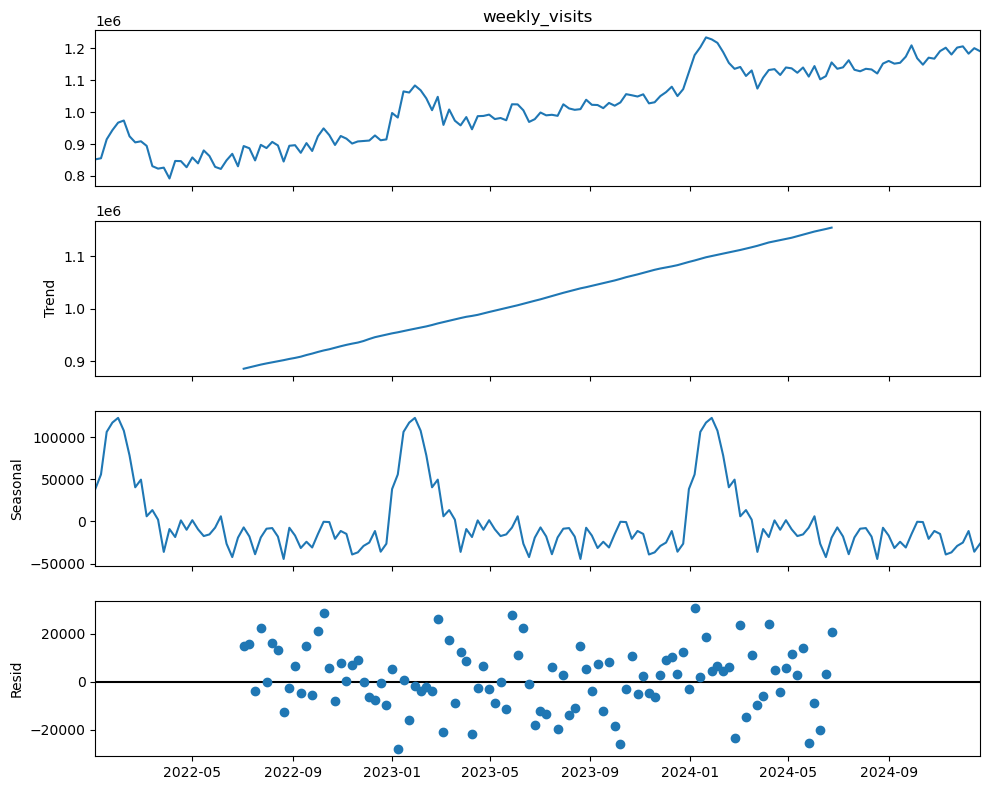

In [82]:
# plotting
# This single command generates a 4-part dashboard
fig = result.plot()
fig.set_size_inches(10, 8)
plt.tight_layout()
plt.show()

In [83]:
# Q2 Stationarity testing: 
# using the raw series from Q1, 
# run the Augmented Dickey-Fuller test. 
# Is the series stationary? 
# Apply first-order differencing and test again. 
# Apply log transformation + differencing if needed. 
# Print p-values at each step and state when stationarity is achieved.

In [ ]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(ts)
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')

if result[1] < 0.05:
    print('Series is stationary')
else:
    print('Series is non-stationary — apply differencing')
    ts_diff = ts.diff().dropna()    # first-order differencing, calculate the difference between this week and last week
    result2 = adfuller(ts_diff)     # Now run the ADF test again
    print(f'After differencing p-value: {result2[1]:.4f}')

# the stationary is achieved after applying first-order differencing
# We would try log-transform if the series had exponential growth or heteroscedastic variance before differencing.

ADF Statistic: -0.6204
p-value: 0.8663
Series is non-stationary — apply differencing
After differencing p-value: 0.0000


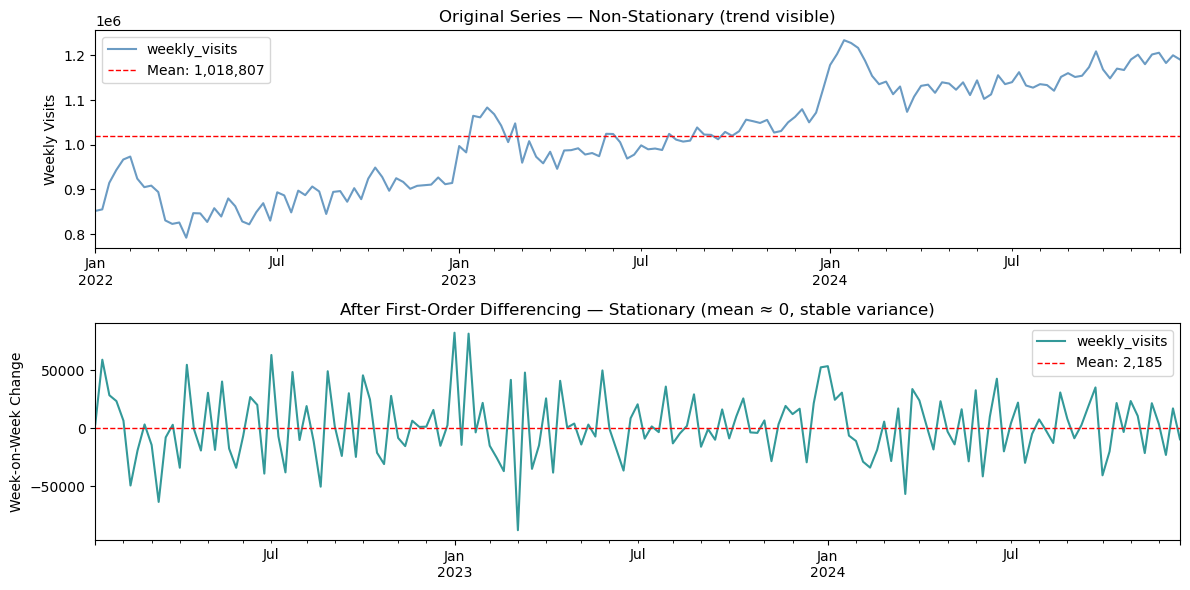

In [101]:
# plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=False)

# Original series — shows trend + seasonality
ts.plot(ax=ax1, color='steelblue', alpha=0.8)
ax1.axhline(ts.mean(), color='red', linestyle='--', linewidth=1, label=f'Mean: {ts.mean():,.0f}')
ax1.set_title('Original Series — Non-Stationary (trend visible)')
ax1.set_ylabel('Weekly Visits')
ax1.legend()

# Differenced series — should be flat around zero
ts_diff.plot(ax=ax2, color='teal', alpha=0.8)
ax2.axhline(0, color='red', linestyle='--', linewidth=1, label=f'Mean: {ts_diff.mean():,.0f}')
ax2.set_title('After First-Order Differencing — Stationary (mean ≈ 0, stable variance)')
ax2.set_ylabel('Week-on-Week Change')
ax2.legend()

plt.tight_layout()
plt.show()

In [85]:
# Q3 Autocorrelation analysis: 
# compute ACF and PACF values for the stationary series from Q2 (use nlags=52). 
# Print the first 10 ACF values. 
# At what lag does the ACF first drop below 0.1? 
# What does this tell you about how many weeks of history are useful for forecasting?

[ 1.         -0.2376863   0.06089701  0.10789539 -0.14152058  0.05904631
 -0.0551515  -0.23497842  0.04966122 -0.10097014]


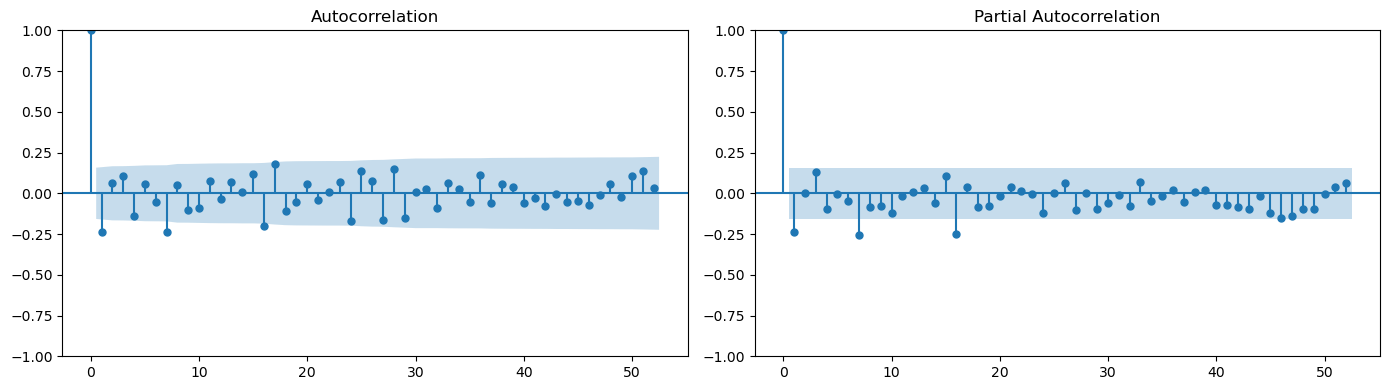

In [102]:
from statsmodels.tsa.stattools import acf, pacf

# ACF: correlation with lags 1, 2, 3... periods back
acf_values = acf(ts_diff, nlags=52)
print(acf_values[:10])

# PACF: partial autocorrelation (controlling for intermediate lags)
pacf_values = pacf(ts_diff, nlags=52)



# Add the plots — these are the standard Q3 deliverables
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(ts_diff, lags=52, ax=ax1)
plot_pacf(ts_diff, lags=52, ax=ax2)
plt.tight_layout()
plt.show()

In [ ]:
lag_threshold = 0.1
first_lag_below = next(i for i, val in enumerate(acf_values[1:], 1) if abs(val) < lag_threshold)

print(f"\nThe ACF first drops below {lag_threshold} at Lag: {first_lag_below}")


The ACF first drops below 0.1 at Lag: 2


```
The ACF dropping quickly below 0.1 indicates that the series has a short memory, meaning only the most recent 1–2 weeks of data are useful for predicting the immediate next value. 
Because the correlation vanishes so fast, a simple model with a small lookback window is better than one using many months of history, which would likely just add noise.

In [88]:
# Q4 Seasonality deep dive: 
# create a daily traffic series for 2 full years (730 days) with both weekly seasonality (Mon-Fri higher) 
# and annual seasonality (flu season spike, summer dip). 
# Group the data by (a) day of week and (b) month of year to compute average traffic. 
# Print both tables and identify peak and trough periods.

In [105]:
np.random.seed(420)

# Setup Dates (2 years = 730 days)
dates = pd.date_range('2024-01-01', periods=730, freq='D')
n_days = 730

# Weekly pattern: Mon-Fri higher, weekends lower
weekly = np.array([1.2, 1.3, 1.1, 1.2, 1.0, 0.7, 0.7])
weekly_effect = np.array([weekly[d.weekday()] for d in dates])

# Annual: Cosine wave for Jan peak (flu) and July trough (summer)
# Center it at 1.0 and give it a 0.15 amplitude
annual = 1 + 0.15 * np.cos(2 * np.pi * (dates.month - 1) / 12)


# Noise and Base
base_traffic = 1000000
noise = np.where(
    np.random.random(n_days) < 0.02,            # 2% of days
    np.random.normal(0, 200000, n_days),        # big spike
    np.random.normal(0, 10000, n_days)          # normal noise
)
traffic = base_traffic * weekly_effect * annual + noise

# Create a DF
df = pd.DataFrame({'traffic': traffic}, index=dates)
display(df.head())


,traffic
2024-01-01,1.360695e+06
2024-01-02,1.487275e+06
2024-01-03,1.262416e+06
2024-01-04,1.374114e+06
2024-01-05,1.165662e+06


In [106]:
# Group by day of week
dow_avg = df.groupby(df.index.dayofweek).mean()
print('Traffic by day of week (0=Mon):')
print(dow_avg)

Traffic by day of week (0=Mon):
        traffic
0  1.200674e+06
1  1.303751e+06
2  1.104842e+06
3  1.200500e+06
4  9.996261e+05
5  7.022869e+05
6  7.032456e+05


In [107]:
# Group by month to find seasonal patterns
monthly_avg = df.groupby(df.index.month).mean()
print('Monthly average traffic:')
print(monthly_avg)

Monthly average traffic:
         traffic
1   1.198084e+06
2   1.178530e+06
3   1.085069e+06
4   1.040735e+06
5   9.591367e+05
6   8.835755e+05
7   8.891451e+05
8   8.817755e+05
9   9.536593e+05
10  1.051087e+06
11  1.089031e+06
12  1.174983e+06


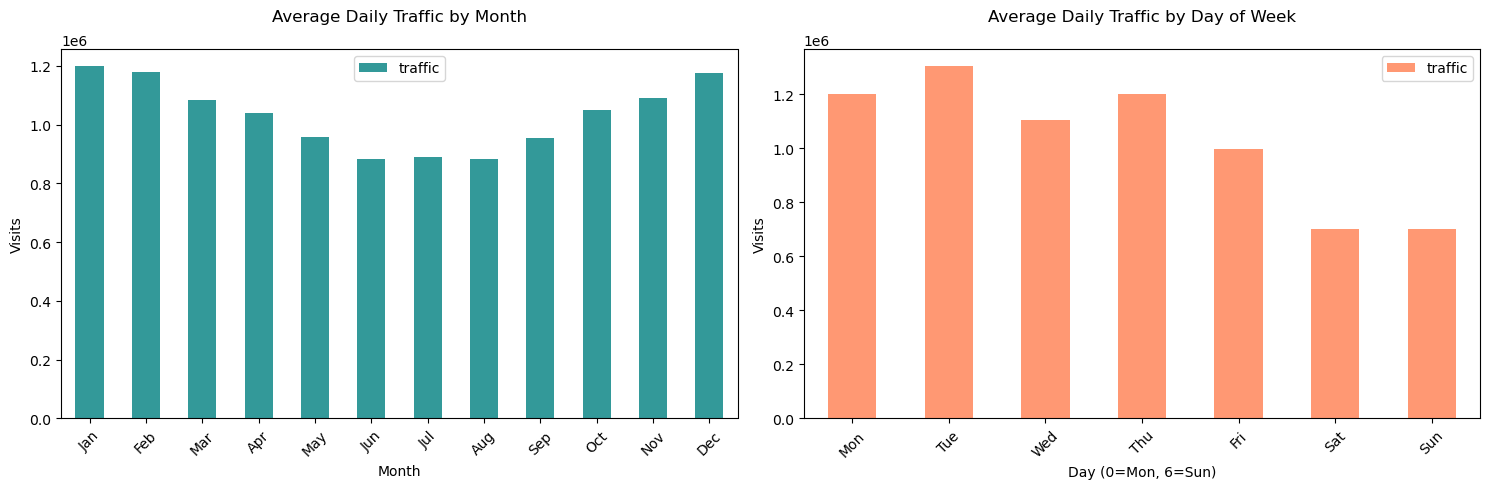

In [108]:
# plotting

import matplotlib.pyplot as plt

# Create a figure with two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 1. Plot Monthly Averages (The "Flu Season" view)
monthly_avg.plot(kind='bar', ax=ax1, color='teal', alpha=0.8)
ax1.set_title('Average Daily Traffic by Month', pad=20)
ax1.set_xlabel('Month')
ax1.set_ylabel('Visits')
ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)

# 2. Plot Day of Week Averages (The "User Habit" view)
dow_avg.plot(kind='bar', ax=ax2, color='coral', alpha=0.8)
ax2.set_title('Average Daily Traffic by Day of Week', pad=20)
ax2.set_xlabel('Day (0=Mon, 6=Sun)')
ax2.set_ylabel('Visits')
ax2.set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], rotation=45)

plt.tight_layout()
plt.show()


In [93]:
# Q5 Rolling statistics and anomaly detection: 
# using the daily series from Q4, 
# compute a 7-day rolling mean and 7-day rolling standard deviation. 
# Define an anomaly as any day where traffic deviates more than 2 standard deviations from the rolling mean. 
# Print how many anomalies were detected and list the top 5 largest deviations.

In [109]:
# Compute 7-day rolling statistics
df['rolling_mean'] = df['traffic'].rolling(window=7).mean()
df['rolling_std'] = df['traffic'].rolling(window=7).std()

# Define Anomaly: Traffic outside of 2 Standard Deviations
df['is_anomaly'] = (np.abs(df['traffic'] - df['rolling_mean']) > (2 * df['rolling_std']))

# Calculate Deviation Magnitude for sorting
df['deviation_score'] = np.abs(df['traffic'] - df['rolling_mean']) / df['rolling_std']

# Filter and Print
anomalies = df[df['is_anomaly'] == True]
print(f"Total Anomalies: {len(anomalies)}")

print("\nTop 5 Largest Deviations:")
print(anomalies[['traffic', 'rolling_mean', 'deviation_score']].sort_values(by='deviation_score', ascending=False).head(5))


Total Anomalies: 1

Top 5 Largest Deviations:
                  traffic  rolling_mean  deviation_score
2025-03-01  759041.658764  1.236062e+06         2.044366


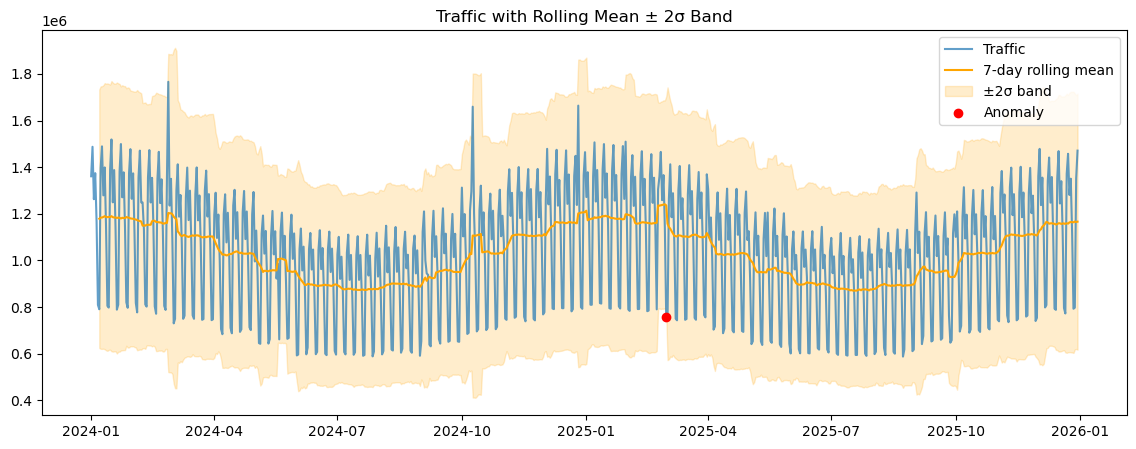

In [110]:
# plotting a shaded band chart

plt.figure(figsize=(14, 5))
plt.plot(df['traffic'], label='Traffic', alpha=0.7)
plt.plot(df['rolling_mean'], label='7-day rolling mean', color='orange')
plt.fill_between(df.index,
                 df['rolling_mean'] - 2*df['rolling_std'],
                 df['rolling_mean'] + 2*df['rolling_std'],
                 alpha=0.2, color='orange', label='±2σ band')
anomaly_points = df[df['is_anomaly']]
plt.scatter(anomaly_points.index, anomaly_points['traffic'],
            color='red', zorder=5, label='Anomaly')
plt.legend()
plt.title('Traffic with Rolling Mean ± 2σ Band')
plt.show()